# plotfmt.ipynb


In [1]:
from peaks import load_experiment
exp = load_experiment("/Users/haoxin/Documents/实验数据/BP260623/data")
print(f"gold={len(exp.gold)}; needs_conversion={len(exp.needs_conversion)}; conflicts={len(exp.conflicts)}")

load_experiment: 28 record(s); gold=[20]; cuts=14; mappings=12; conflicts=1; metadata=datasheet
gold=1; needs_conversion=0; conflicts=1


In [2]:
for c in exp.conflicts:
    print(f"conflict index={c.index} format={c.data_format} dims={tuple(c.dims)} issue={c.issue}")

conflict index=26 format=sweep dims=('eV', 'theta_par', 'deflector_perp') issue=record declared 'sweep' carries extra dimensions; keep it as a cut and select the intended scanned-axis plane


EF_poly4=2.6608 fit_window=[2.623,2.701] pts=13/13 outlier=0.027 uniform=True


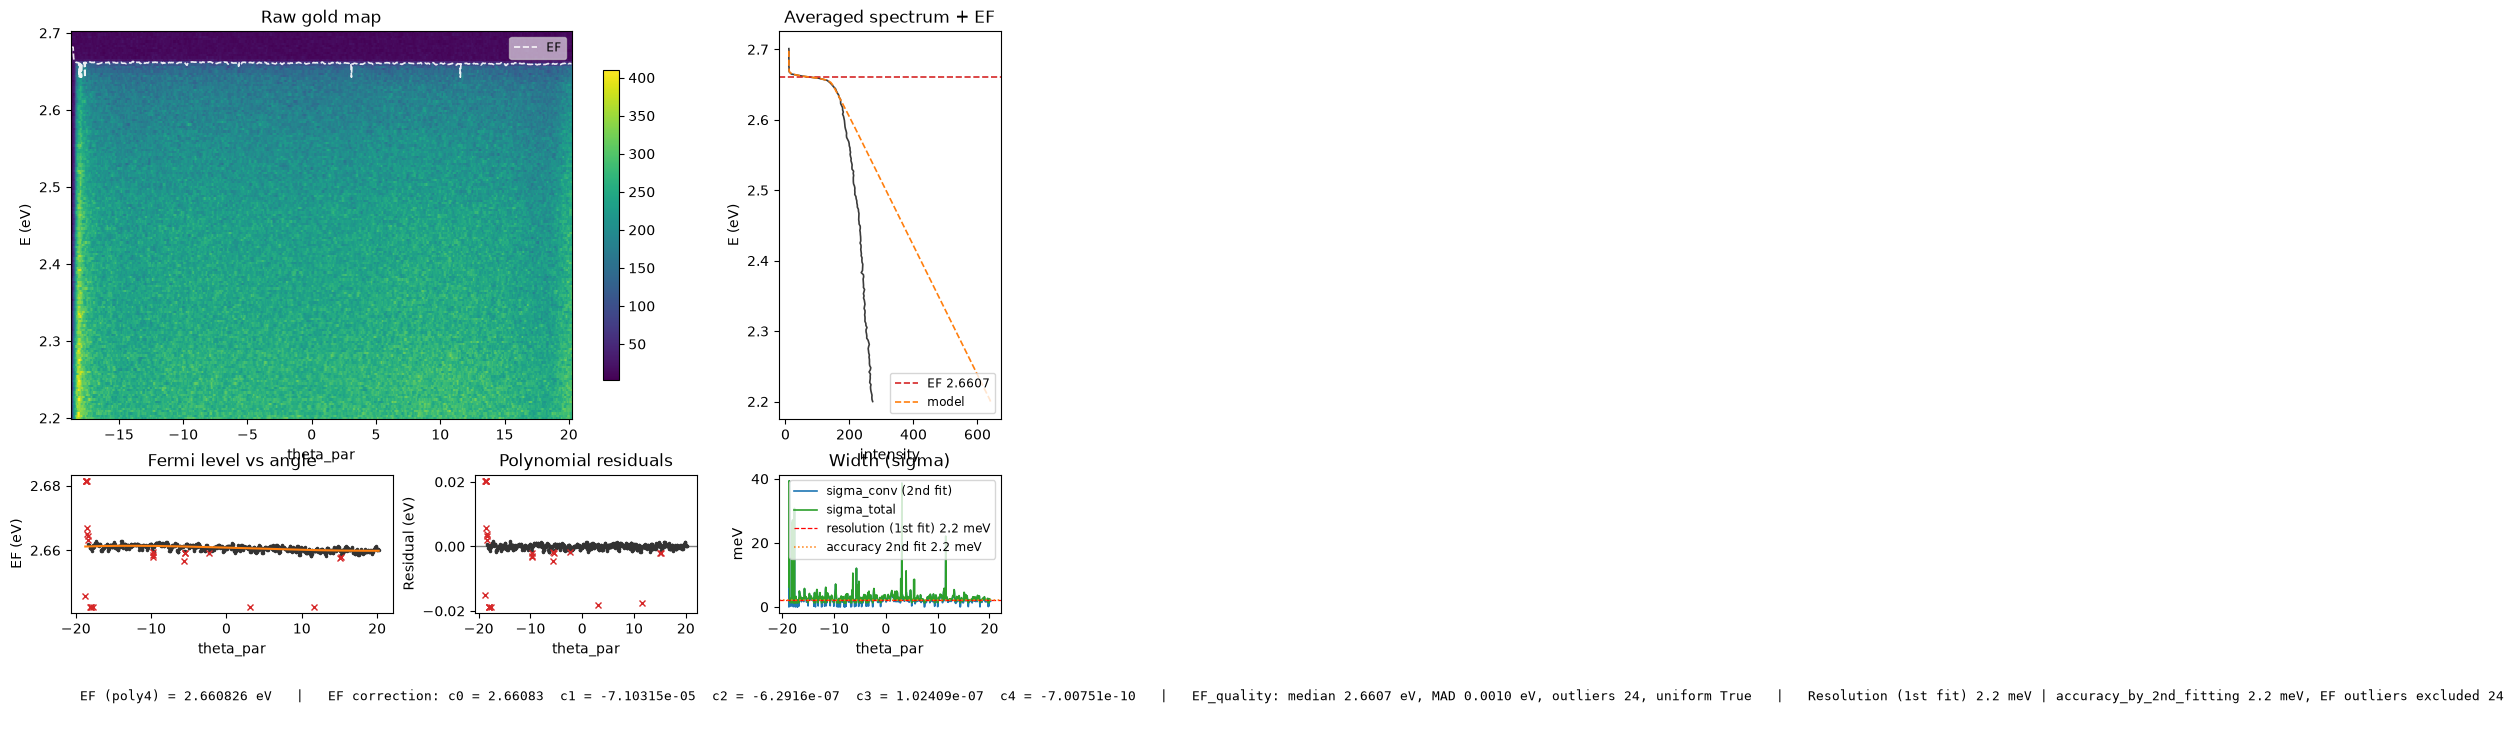

In [3]:
records_by_index = {record.index: record for record in exp.records}
gold_index = exp.gold[0]
gold_record = records_by_index[gold_index]
gold = exp[gold_index]
gold_fit = gold.fit_gold(show=False, quiet=True)
fw = gold_fit.attrs["fit_window"]; q = gold_fit.attrs["EF_quality"]
print(f"EF_poly4={gold_fit.attrs['EF_poly4']:.4f} fit_window=[{fw['start_eV']:.3f},{fw['stop_eV']:.3f}] pts={fw['lower_points']}/{fw['upper_points']} outlier={q['outlier_fraction']:.3f} uniform={q['uniform']}")
gold_figure = gold_fit.attrs["figure"]
gold_figure

In [4]:
result_dict = {}
theta_by_stem = {}
representative_raw = None
representative_kcut = None
rep_stem = None
failures = []
for cut_index in exp.cuts:
    record = records_by_index[cut_index]
    raw = exp[cut_index]
    if cut_index == 26:
        raw = raw.sel(deflector_perp=0.0)
    try:
        zeroed = raw.metadata.assign_normal_emission(theta_par=record.theta_offset_deg)
        kcut = zeroed.k_convert(EF_correction=gold_fit, quiet=True)
    except Exception as exc:
        failures.append(f"{record.stem}:{type(exc).__name__}")
        continue
    result_dict[record.stem] = kcut
    theta_by_stem[record.stem] = record.theta_offset_deg
    if representative_raw is None:
        representative_raw = raw
        representative_kcut = kcut
        rep_stem = record.stem
print("processed_stems=" + ",".join(sorted(result_dict)))
emins = [float(v.eV.min()) for v in result_dict.values()]
emaxs = [float(v.eV.max()) for v in result_dict.values()]
zero_crossed = sum(1 for v in result_dict.values() if float(v.eV.min()) <= 0.0 <= float(v.eV.max()))
print(f"cuts={len(result_dict)} e_min=[{min(emins):.3f},{max(emins):.3f}] e_max=[{min(emaxs):.3f},{max(emaxs):.3f}] zero_crossed={zero_crossed}/{len(result_dict)}")
print(f"failures={failures}")

processed_stems=BP_0005,BP_0006,BP_0009,BP_0010,BP_0011,BP_0012,BP_0015,BP_0016,BP_0019,BP_0021,BP_0022,BP_0025,BP_0026,BP_0027
cuts=14 e_min=[-1.941,-0.461] e_max=[0.043,3.544] zero_crossed=14/14
failures=[]


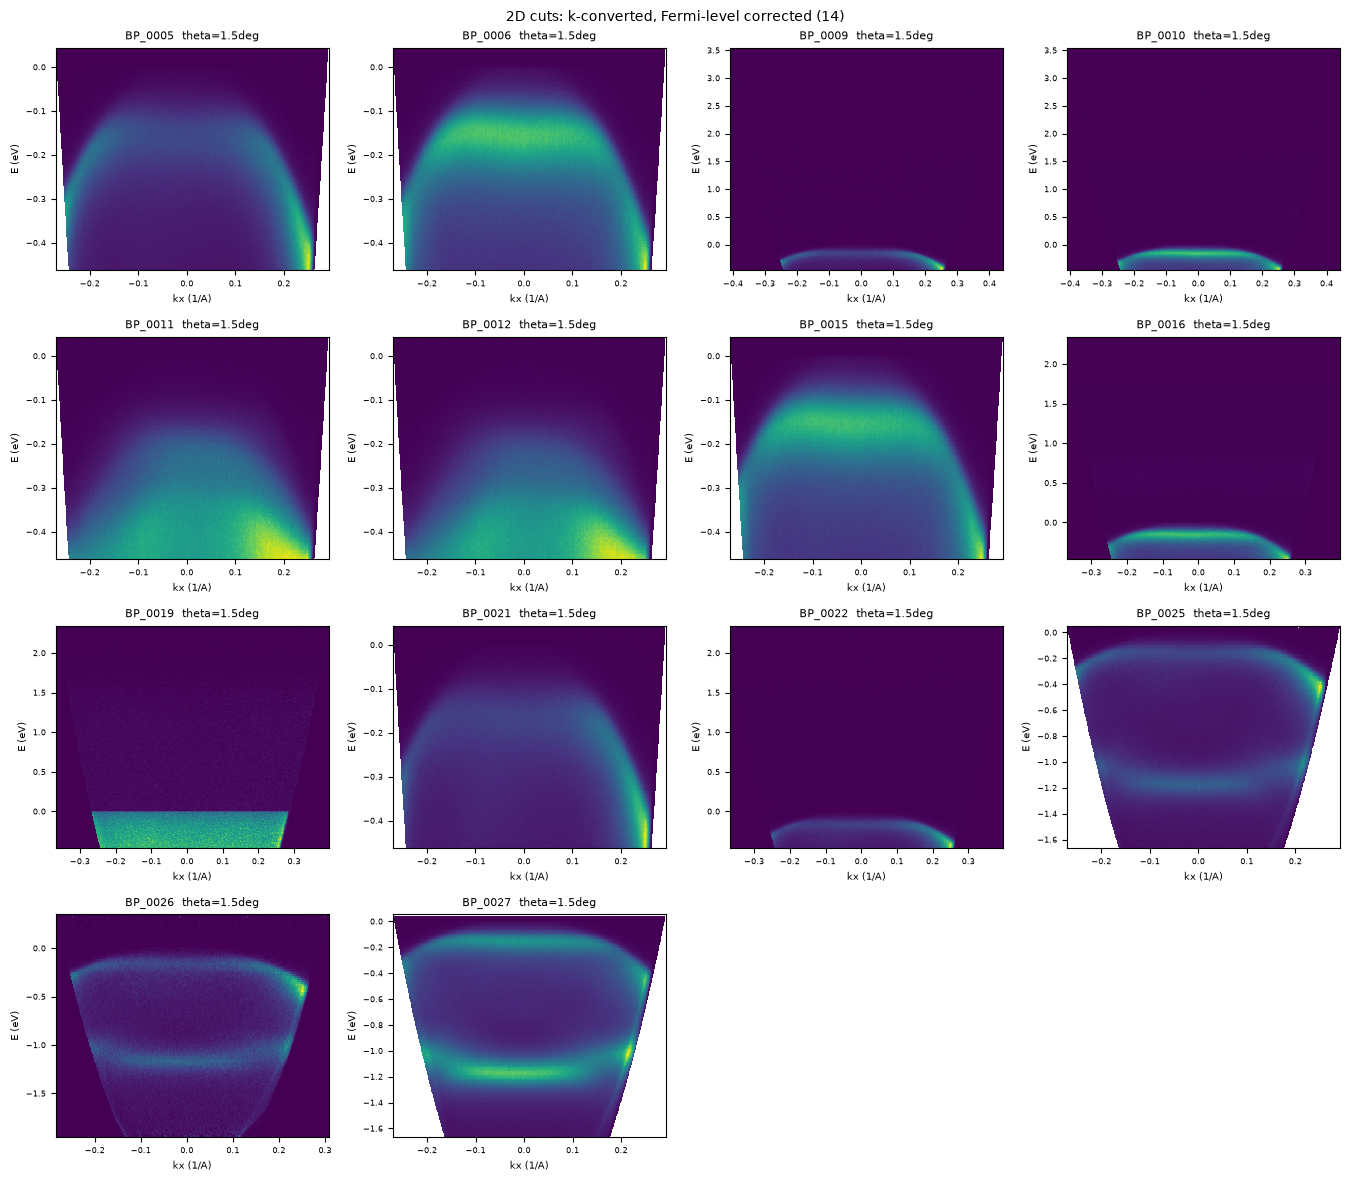

In [5]:
import peaks
grid_figure = peaks.plot_cut_grid(result_dict, theta_by_stem)
grid_figure

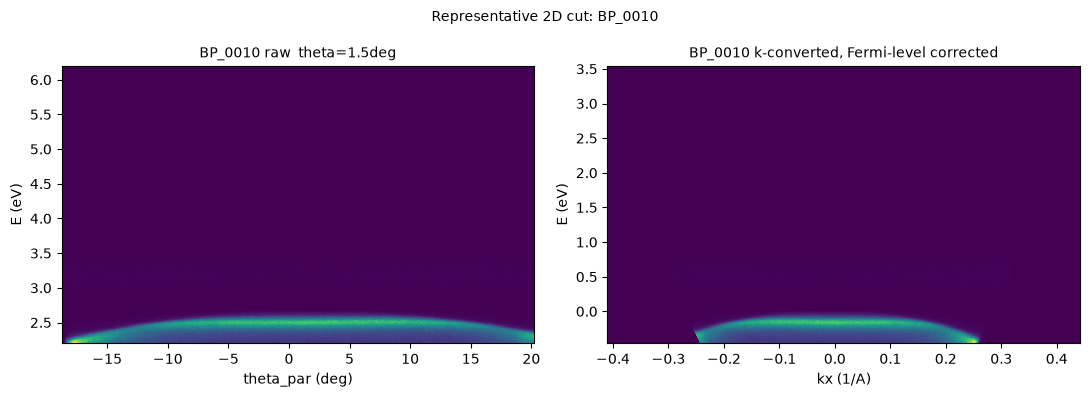

In [6]:
import peaks
cmp_figure = peaks.plot_before_after(representative_raw, representative_kcut, rep_stem, theta_by_stem)
cmp_figure

In [7]:
print(f"gold={gold_record.stem} (index {gold_index})")
print(f"rep={rep_stem} theta_offset={theta_by_stem[rep_stem]} deg from record.theta_offset_deg")
thetas = [theta_by_stem[s] for s in sorted(theta_by_stem)]
print(f"theta_range=[{min(thetas)},{max(thetas)}] n={len(thetas)}")

gold=BP_0020 (index 20)
rep=BP_0010 theta_offset=1.5 deg from record.theta_offset_deg
theta_range=[1.5,1.5] n=14


# 2D cut preprocessing — BP260623

All 14 2D cuts from `/Users/haoxin/Documents/实验数据/BP260623/data` were preprocessed in the live kernel and kept in the live dictionary **`result_dict`** (stem → k-converted, Fermi-corrected 2D DataArray).

`processed_stems=BP_0005,BP_0006,BP_0009,BP_0010,BP_0011,BP_0012,BP_0015,BP_0016,BP_0019,BP_0021,BP_0022,BP_0025,BP_0026,BP_0027`

- Gold reference: **gold=BP_0020 (index 20)**. One fit: `EF_poly4=2.6608`, window [2.623, 2.701] eV, points 13/13, outlier_fraction=0.027, uniform=True. Fit reused for every cut.
- Angular correction: **theta_offset=1.5 deg from record.theta_offset_deg** (identical for all 14 cuts; range [1.5, 1.5]).
- Cache: **preconverted cache reused** (`needs_conversion=0`; no `pxt2nc` call).
- Pipeline per cut: `raw.metadata.assign_normal_emission(theta_par=record.theta_offset_deg)` → `.k_convert(EF_correction=gold_fit, quiet=True)`.
- Conflict: index 26 declared `sweep` but carried an extra `deflector_perp` dimension; resolved by selecting the physical zero plane `.sel(deflector_perp=0.0)` before conversion.
- Validation: **zero_crossed=14/14** (every processed eV axis crosses 0).
- Figures: gold diagnostic (`gold_figure`), compact all-cut grid (`grid_figure`), representative before/after (`cmp_figure`, rep stem `BP_0010`).
- Failed/unprocessed items: **none** (`failures=[]`).

Processed results were not persisted; no files were written.